In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

estimating categorical probs
estimating approx kdes(histogram)
[0.6689960194604158]
Attacking : Raw
Generated datasest of Raw stored at :data/generated_datasets/Raw.pkl
COMPLEXITY:  2
COMPLEXITY:  20


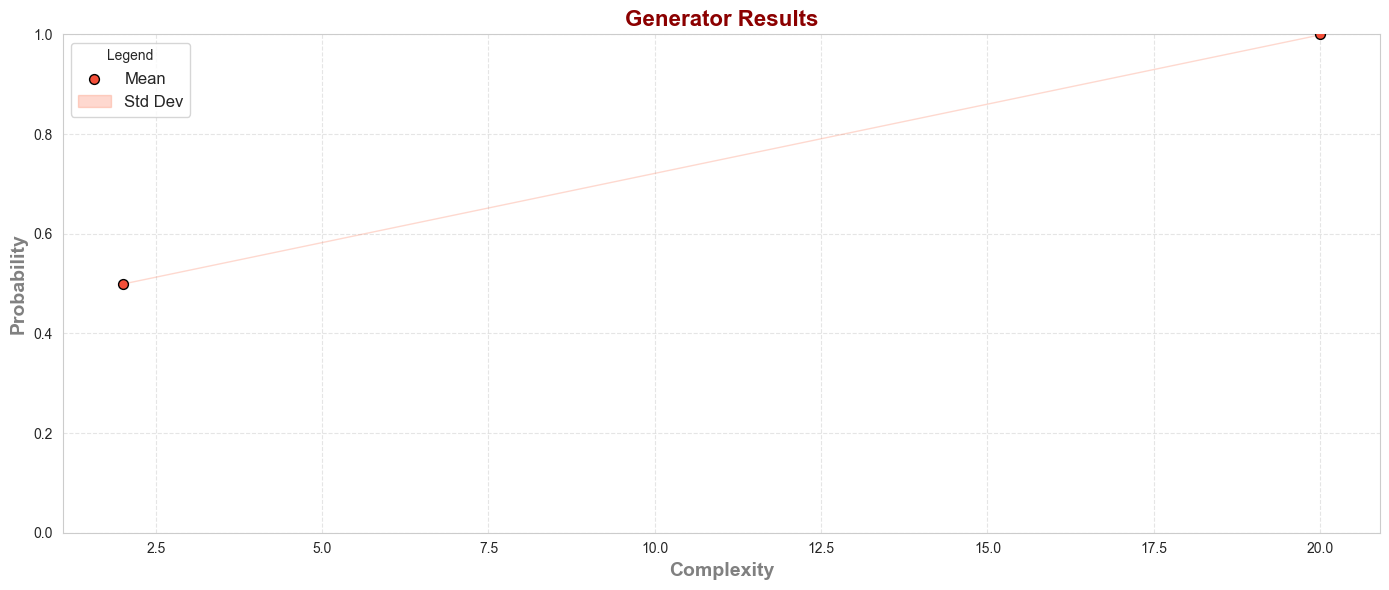

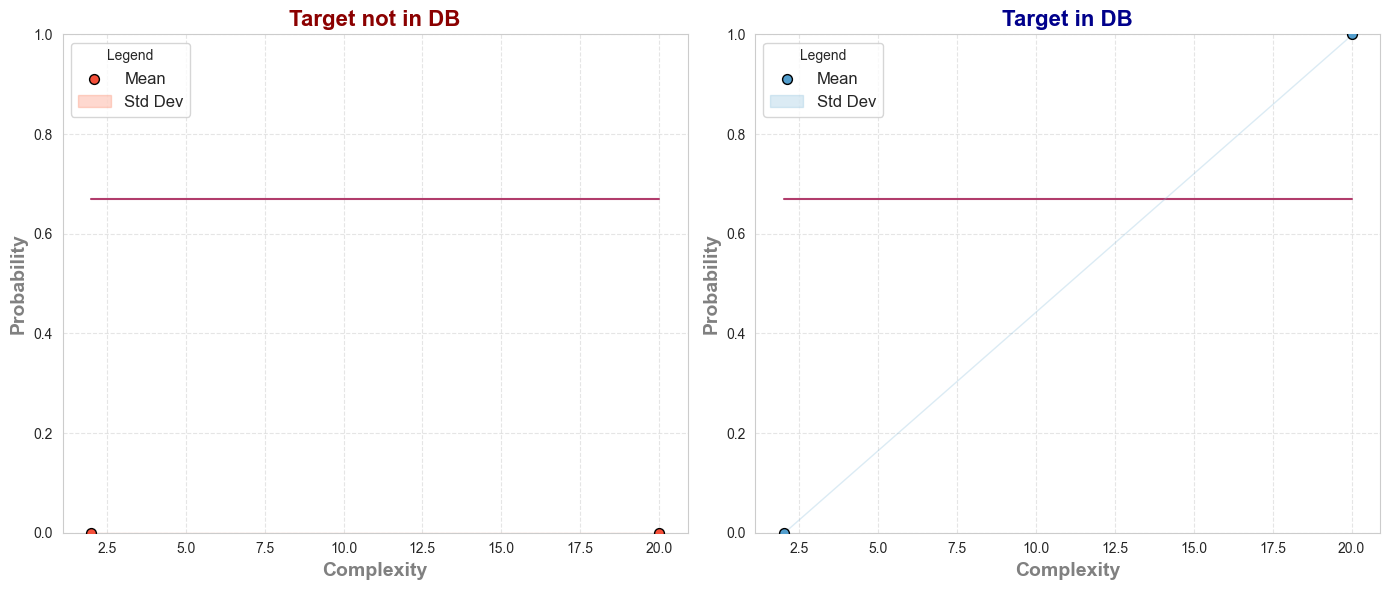

Attacking : PrivBayes_epsilon=1.0
Generated datasest of PrivBayes stored at :data/generated_datasets/PrivBayes_epsilon=1.0.pkl
COMPLEXITY:  2
COMPLEXITY:  20


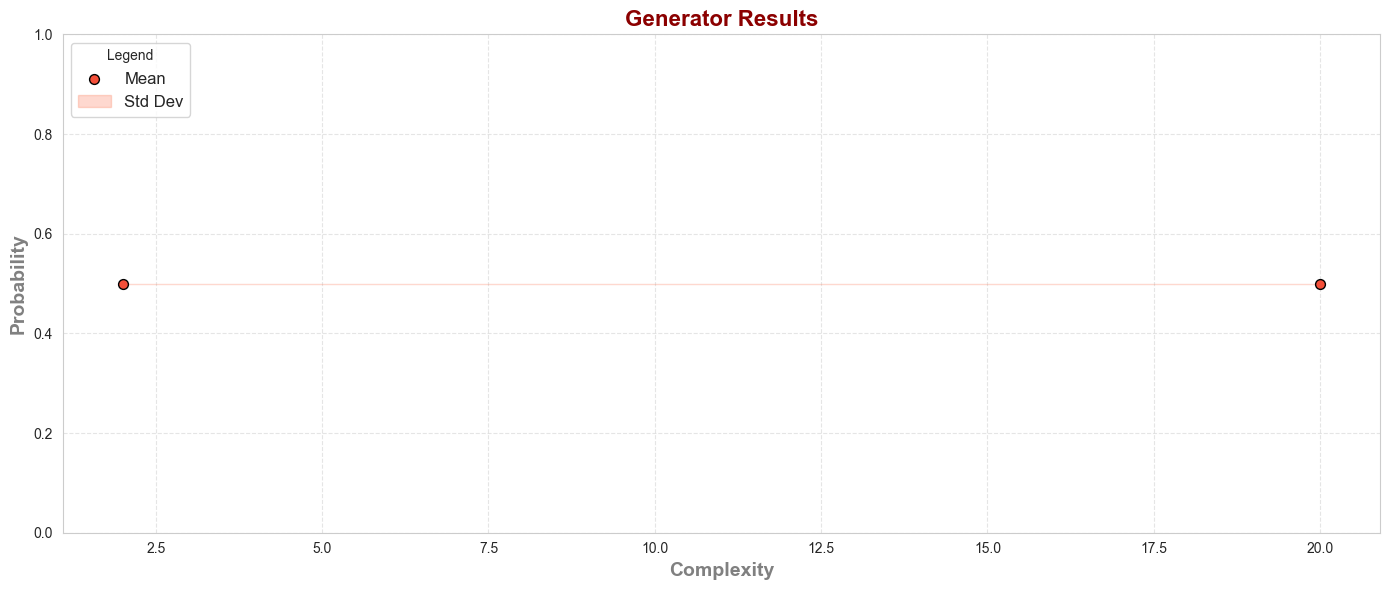

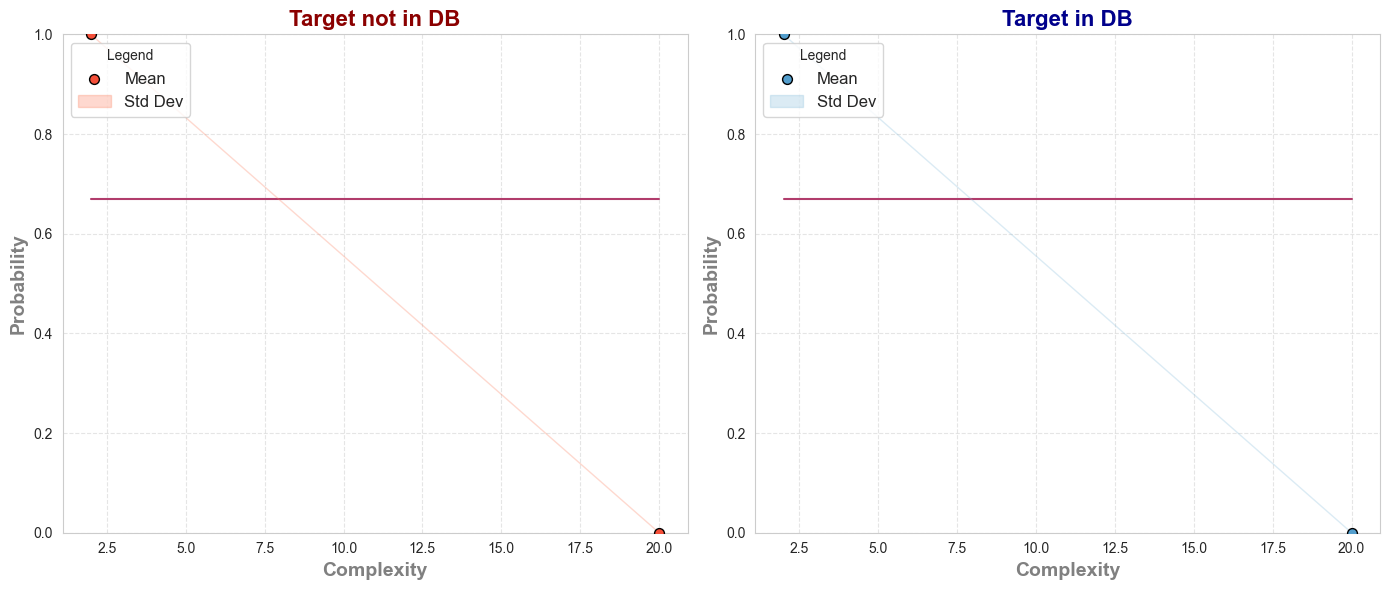

----[Benchmark ranks]----
Raw : E, 0.75
Raw was not broken by the attack
PrivBayes : D, 0.5
PrivBayes was not broken by the attack
Generators Metrics saved to results/2025_05_20_18_54/generators_metrics.csv
Attack results saved to results/2025_05_20_18_54/attack_results.yaml


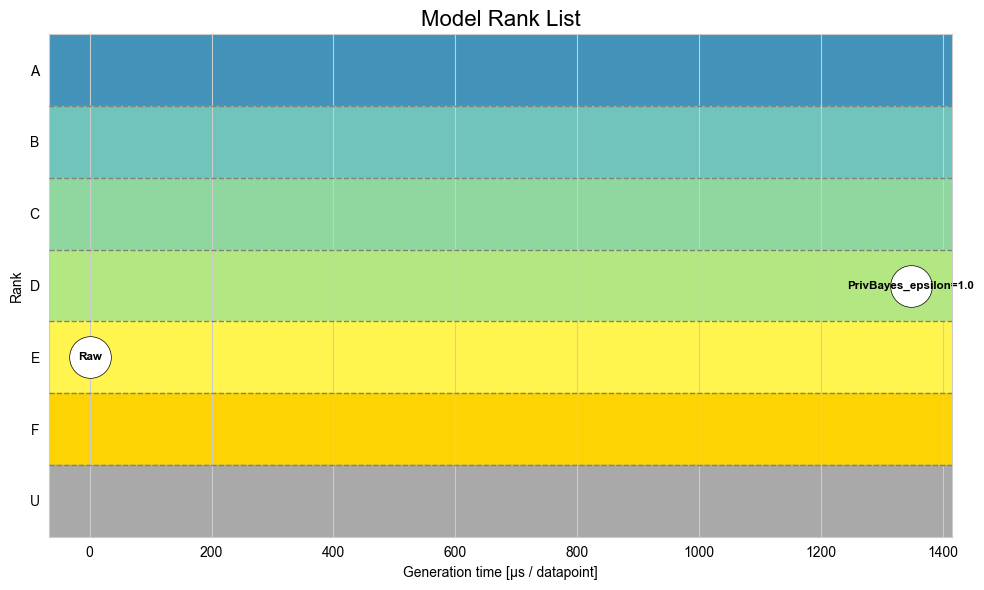

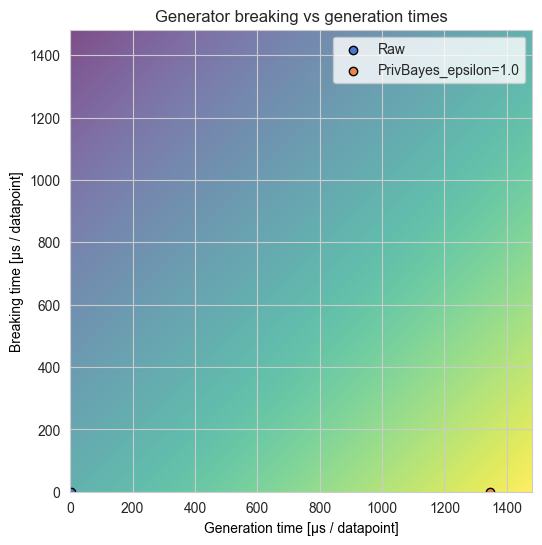

Evaluating original data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : Raw
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : PrivBayes_epsilon=1.0
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results saved to results/2025_05_20_18_54/results_ml_utility.csv
Evaluating : Raw
Evaluating : PrivBayes_epsilon=1.0


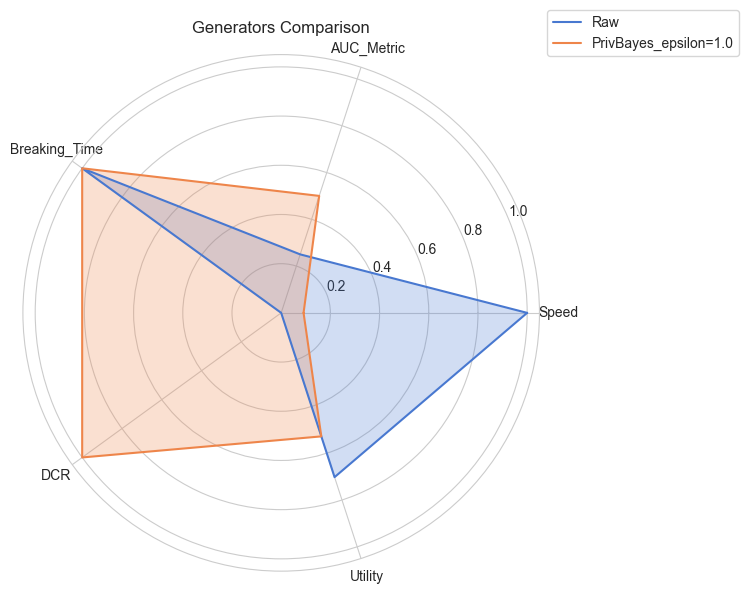

In [2]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2))

gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(),gen], target_record=target_record)
benchmarking_metric = AUCMetric()


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='all', benchmarking_metric=benchmarking_metric, 
classification_target_col="income", dcr_metric="gower", generate_data=True)

In [3]:
import numpy as np
import pandas as pd
import gower
Xd=pd.DataFrame({'age':[21,21,19, 30,21,21,19,30,None],
'gender':['M','M','N','M','F','F','F','F',None],
'civil_status':['MARRIED','SINGLE','SINGLE','SINGLE','MARRIED','SINGLE','WIDOW','DIVORCED',None],
'salary':[3000.0,1200.0 ,32000.0,1800.0 ,2900.0 ,1100.0 ,10000.0,1500.0,None],
'has_children':[1,0,1,1,1,0,0,1,None],
'available_credit':[2200,100,22000,1100,2000,100,6000,2200,None]})
Yd = Xd.iloc[1:3,:]
X = np.asarray(Xd)
Y = np.asarray(Yd)

In [4]:
import tapas
import numpy as np
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor
from tapas.datasets.data_description import DataDescription
data2 = tapas.datasets.TabularDataset.read("data/adult")
description = DataDescription(data2.description.schema)
df = data2.data
# keep only first 5 rows
df = df.iloc[:5, :]
data2 = tapas.datasets.TabularDataset(df, description)
data2.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [5]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2))
pipeline2 = BenchmarkPipeline(data2, attack, [Raw()], target_record=target_record)
pipeline2._average_dcr(num_samples=2, metric="gower",store_results=False)

Evaluating : Raw


In [6]:
# 
g_matrix = [[0.   ,      1.1626667 ],
 [1.1641475 , 1.1905192 ],
 [1.1490746 , 0.50248104],
 [1.2108377  ,0.559829  ],
 [1.1626667 , 0.        ]]
# take minimum for each column in the matrix

# turn g_matrix into a np.array
g_matrix = np.array(g_matrix)
min_gower = np.min(g_matrix, axis=0)
print(min_gower)

[0. 0.]
